In [4]:
import numpy as np
import matplotlib.pyplot as plt 

In [12]:
word_embadding = {
    # Pets / farm animals
    "cat": [0.82, 0.24],
    "dog": [0.86, 0.28],
    "horse": [0.70, 0.35],

    # Wild animals
    "lion": [0.41, 0.78],
    "elephant": [0.30, 0.82],
    "monkey": [0.36, 0.69],

    # Reptile / aquatic
    "fish": [0.12, 0.35],
    "snake": [0.20, 0.55],

    # Ground transport
    "car": [0.82, -0.14],
    "bicycle": [0.90, -0.08],

    # Air/sea transport
    "airplane": [0.42, -0.76],
    "ship": [0.28, -0.62],

    # Weapons
    "gun": [-0.62, -0.54],
    "sword": [-0.58, -0.43],
}



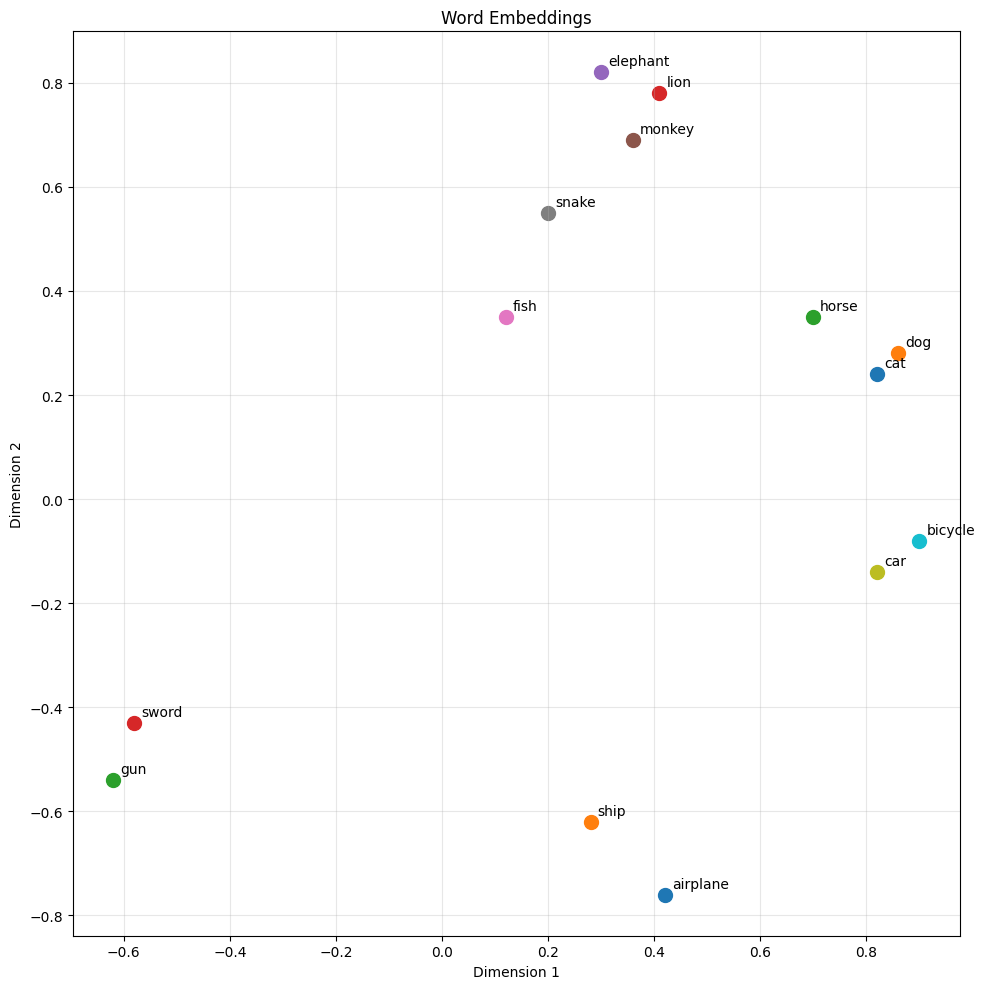

In [13]:
fix,ax = plt.subplots(figsize=(10,10))

for word,embadding in word_embadding.items():
    ax.scatter(embadding[0],embadding[1],marker='o', s=100)
    ax.annotate(word,xy=(embadding[0],embadding[1]),xytext=(5,5),
                textcoords='offset points',
                )

ax.set_xlabel('Dimension 1')
ax.set_ylabel('Dimension 2')
ax.set_title('Word Embeddings')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


## Measuring Similarity

In [14]:
def cosine_similarity(vec1,vec2):
    """
    Cosine similarity measures the angle between two vectors.
    - Result close to 1 means vectors are similar
    - Result close to 0 means vectors are dissimilar
    - Result close to -1 means vectors are opposite
    """
    # Calculate dot product of the vectors
    dot_product = np.dot(vec1,vec2)
    # Calculate the magnitude of the vectors
    magnitude_vec1 = np.linalg.norm(vec1)
    magnitude_vec2 = np.linalg.norm(vec2)
    
    # Calculate the cosine similarity
    return dot_product / (magnitude_vec1 * magnitude_vec2)


In [18]:
cat_kitten = cosine_similarity(word_embadding['cat'],word_embadding['dog'])
print(f"Cosine similarity between cat and dog: {cat_kitten}")

Cosine similarity between cat and dog: 0.9995492168150517


In [19]:
cat_car = cosine_similarity(word_embadding['cat'],word_embadding['car'])
print(f"Cosine similarity between cat and car: {cat_car}")

Cosine similarity between cat and car: 0.8987738544067202


## creating first embedding

In [ ]:
from langchain_huggingface import HuggingFaceEmbeddings

## initialize a simple embedding model (No Api Key Required)
embeddings = HuggingFaceEmbeddings(
    model_name = "sentence-transformers/all-MiniLM-L6-v2",
    model_kwargs = {'device': 'cpu'}
)

## Embed a text
text = "Hello, how are you?"
embedding = embeddings.embed_query(text)
print(f"Embedding shape: {embedding.shape}")
print(f"embadding length: {len(embedding)}")
print(embedding)





Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


[0.01909676566720009, 0.03446516767144203, 0.09162797033786774, 0.07016526162624359, -0.029946591705083847, -0.08419135957956314, 0.04581356793642044, 0.004958597011864185, -0.09189329296350479, 0.017400626093149185, -0.008816120214760303, -0.0006614791345782578, -0.028556939214468002, -0.021949762478470802, 0.05516674369573593, -0.04983651265501976, 0.08988090604543686, -0.08895713835954666, -0.11235620826482773, 0.03900054842233658, -0.06607077270746231, 0.026095159351825714, 0.03653070330619812, 0.06139037385582924, -0.057124942541122437, -0.054639365524053574, 0.030365554615855217, 0.03238753229379654, 0.012644686736166477, -0.10568572580814362, -0.058345530182123184, 0.06732939183712006, -0.04075591266155243, 0.006439787335693836, 0.005698686465620995, 0.05285322293639183, -0.03977528214454651, -0.11855249106884003, 0.002116164658218622, -0.016692833974957466, 0.028338100761175156, -0.03743794932961464, -0.021371381357312202, -0.04147519916296005, 0.08497179299592972, -0.068694271

In [23]:
## Embed a text
text = "Hello, how are you?"
embedding = embeddings.embed_query(text)
print(f"embadding length: {len(embedding)}")
print(embedding)

embadding length: 384
[0.01909676566720009, 0.03446516767144203, 0.09162797033786774, 0.07016526162624359, -0.029946591705083847, -0.08419135957956314, 0.04581356793642044, 0.004958597011864185, -0.09189329296350479, 0.017400626093149185, -0.008816120214760303, -0.0006614791345782578, -0.028556939214468002, -0.021949762478470802, 0.05516674369573593, -0.04983651265501976, 0.08988090604543686, -0.08895713835954666, -0.11235620826482773, 0.03900054842233658, -0.06607077270746231, 0.026095159351825714, 0.03653070330619812, 0.06139037385582924, -0.057124942541122437, -0.054639365524053574, 0.030365554615855217, 0.03238753229379654, 0.012644686736166477, -0.10568572580814362, -0.058345530182123184, 0.06732939183712006, -0.04075591266155243, 0.006439787335693836, 0.005698686465620995, 0.05285322293639183, -0.03977528214454651, -0.11855249106884003, 0.002116164658218622, -0.016692833974957466, 0.028338100761175156, -0.03743794932961464, -0.021371381357312202, -0.04147519916296005, 0.084971792

In [27]:
sentences = ["I love programming in Python",
            "I hate programming in Python",
            "I love programming in Java",
            "I hate programming in Java",
            "I love programming in C++",
            "I hate programming in C++"]

embedding = embeddings.embed_documents(sentences)
print(embedding)

[[-0.05730824917554855, 0.012835572473704815, -0.03422995284199715, 0.023673301562666893, -0.017288044095039368, -0.16942018270492554, 0.03742196783423424, 0.08024062216281891, -0.01947520487010479, 0.032258301973342896, -0.05816471949219704, 0.028526030480861664, 0.06679010391235352, 0.04178887978196144, 0.05896133929491043, -0.028756575658917427, -0.093843974173069, -0.003764533903449774, 0.03511255234479904, -0.13647009432315826, -0.0958661362528801, 0.04298047348856926, -0.010301657021045685, 0.005191263277083635, 0.017639774829149246, -0.014539516530930996, 0.011575618758797646, -0.020057769492268562, -0.014882031828165054, -0.05719557777047157, -0.0722540020942688, 0.10563819855451584, 0.04824923351407051, 0.03698628395795822, 0.004924629349261522, 0.056275758892297745, 0.03693476691842079, -0.06014427915215492, -0.024707132950425148, 0.03538632020354271, -0.050647225230932236, 0.04535137861967087, -0.011765577830374241, -0.06097249686717987, -0.03351769596338272, -0.021420922130